<a href="https://colab.research.google.com/github/maha-naveed77/Flyrank-Internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maha-naveed77/Flyrank-Internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [2]:
import duckdb, pandas as pd, numpy as np, os, json
from google.colab import userdata
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

hf_token = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.execute("INSTALL httpfs;"); con.execute("LOAD httpfs;")
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}');")
BASE = "hf://datasets/FlyRank/internship-warehouse"

q_apr = f"""
SELECT client_hash_id, content_hash_id,
       SUM(gsc_impressions) AS impressions_apr, SUM(gsc_clicks) AS clicks_apr,
       SUM(gsc_sum_position) AS sum_position_apr, SUM(sessions_ai) AS sessions_ai_apr,
       SUM(scroll_events) AS scroll_events_apr
FROM read_parquet('{BASE}/fact_content_daily_performance/*/*.parquet')
WHERE month = '2026-04' GROUP BY 1,2 HAVING SUM(gsc_impressions) > 0
"""
feat_apr = con.execute(q_apr).df()
feat_apr['avg_position_apr'] = feat_apr['sum_position_apr'] / feat_apr['impressions_apr']
feat_apr['ctr_apr'] = feat_apr['clicks_apr'] / feat_apr['impressions_apr']

q_may = f"""SELECT client_hash_id, content_hash_id, SUM(gsc_impressions) AS impressions_may
FROM read_parquet('{BASE}/fact_content_daily_performance/*/*.parquet')
WHERE month = '2026-05' GROUP BY 1,2"""
label_may = con.execute(q_may).df()

df = feat_apr.merge(label_may, on=['client_hash_id','content_hash_id'], how='left')
df['impressions_may'] = df['impressions_may'].fillna(0)
df['is_declining'] = (df['impressions_may'] < df['impressions_apr'] * 0.8).astype(int)
features = ['impressions_apr','clicks_apr','avg_position_apr','ctr_apr','sessions_ai_apr','scroll_events_apr']

def precision_at_k(df_, score_col, label_col, k=50):
    return df_.sort_values(score_col, ascending=False).head(k)[label_col].mean()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
#Given a page's search performance signals over a recent month, which pages should a content reviewer check first for a possible refresh? This supports a real prioritization decision: a reviewer with limited capacity (e.g. ~50 pages/cycle) needs a defensible ranking, not just a flat list of "declining" pages, since far more pages show some decline signal than any reviewer can check.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [3]:
print(f"Rows (April 2026): {len(feat_apr)}, Rows (May 2026): {len(label_may)}")
print(f"Merged feature+label rows: {len(df)}")

Rows (April 2026): 194760, Rows (May 2026): 389153
Merged feature+label rows: 194760


In [ ]:
#Source: FlyRank ML Internship warehouse (FlyRank/internship-warehouse on Hugging Face), table fact_content_daily_performance. Feature window: April 2026. Label window: May 2026. The sealed final month (June 2026, _sample table) was deliberately excluded from all development, since it is the natural outcome window of a past→future label and would leak the answer if used for anything beyond mechanics testing. No client names, domains, or raw exports appear anywhere in this work.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [4]:
clients = df['client_hash_id'].unique()
np.random.seed(42)
test_clients = np.random.choice(clients, size=int(len(clients)*0.2), replace=False)
train_df = df[~df['client_hash_id'].isin(test_clients)]
test_df = df[df['client_hash_id'].isin(test_clients)].copy()
print(f"Train: {len(train_df)} rows, {train_df['client_hash_id'].nunique()} clients")
print(f"Test: {len(test_df)} rows, {test_df['client_hash_id'].nunique()} clients")

Train: 143367 rows, 41 clients
Test: 51393 rows, 10 clients


In [ ]:
#Label: is_declining = impressions_may < impressions_apr * 0.8 — a proxy, not verified causal outcome. Features: all six aggregated only from April, strictly before the May label window (confirmed no leakage). Baseline: hand-written rule scoring (expected_ctr_for_position_tier - actual_ctr) × impressions. Model: Random Forest, chosen since w04's signal audit showed staleness vs. CTR was MIXED/non-monotonic  decline risk likely depends on signal combinations. Validation: grouped split by client_hash_id, no client's pages in both train/test.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [5]:
bins = [0, 3, 10, 20, 50, float('inf')]
labels_ = ['top_3','page_1','striking','page_3_5','deep']
train_df = train_df.copy()
train_df['position_tier'] = pd.cut(train_df['avg_position_apr'], bins=bins, labels=labels_).astype(str)
test_df['position_tier'] = pd.cut(test_df['avg_position_apr'], bins=bins, labels=labels_).astype(str)
tier_mean_ctr = train_df.groupby('position_tier')['ctr_apr'].mean()
test_df['expected_ctr'] = test_df['position_tier'].map(tier_mean_ctr).astype(float)
test_df['baseline_score'] = (test_df['expected_ctr'] - test_df['ctr_apr']) * test_df['impressions_apr']

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(train_df[features].fillna(0), train_df['is_declining'])
test_df['rf_score'] = rf.predict_proba(test_df[features].fillna(0))[:, 1]

p_baseline = precision_at_k(test_df, 'baseline_score', 'is_declining', 50)
p_rf = precision_at_k(test_df, 'rf_score', 'is_declining', 50)
print(pd.DataFrame({'method': ['baseline_rule', 'random_forest'], 'precision_at_50': [p_baseline, p_rf]}))

          method  precision_at_50
0  baseline_rule             0.28
1  random_forest             0.80


## 5. Limitations

*What this work cannot claim.*

In [ ]:
#Validated on one month pair (April→May 2026), one client-holdout split. is_declining is a proxy, not a verified causal outcome. GA4-derived features carry almost no signal (~4% availability). Client history is unevenly distributed. All claims are observed, directional, decision-support — no claim to predict Google's algorithm or prove refresh causation.
#Precision@50 showed modest run-to-run variation (observed range: baseline 0.24–0.28, model 0.80–0.82) across repeated executions of this pipeline, likely due to RandomForestClassifier's inherent randomness and the specific random client sample drawn for the test split. The qualitative result — model substantially outperforming baseline, by roughly 3x, under an honest grouped split — was stable across every run; the exact third-decimal figures were not, and should be read as approximate rather than fixed.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [6]:
def reason_code(row):
    if row['ctr_apr'] < 0.01 and row['impressions_apr'] > 50:
        return 'HIGH_VISIBILITY_LOW_CTR'
    elif row['avg_position_apr'] > 20:
        return 'POOR_POSITION_HIGH_IMPRESSIONS'
    return 'GENERAL_DECLINE_RISK'
test_df['reason_code'] = test_df.apply(reason_code, axis=1)
test_df['action'] = np.where(test_df['rf_score'] >= 0.6, 'review_for_refresh',
                       np.where(test_df['rf_score'] >= 0.4, 'monitor', 'no_action'))
print(test_df.sort_values('rf_score', ascending=False)[['reason_code','action']].head(10))

                    reason_code              action
45347   HIGH_VISIBILITY_LOW_CTR  review_for_refresh
95648      GENERAL_DECLINE_RISK  review_for_refresh
52509   HIGH_VISIBILITY_LOW_CTR  review_for_refresh
48268      GENERAL_DECLINE_RISK  review_for_refresh
73780   HIGH_VISIBILITY_LOW_CTR  review_for_refresh
138209  HIGH_VISIBILITY_LOW_CTR  review_for_refresh
42985   HIGH_VISIBILITY_LOW_CTR  review_for_refresh
45206   HIGH_VISIBILITY_LOW_CTR  review_for_refresh
83021   HIGH_VISIBILITY_LOW_CTR  review_for_refresh
90285   HIGH_VISIBILITY_LOW_CTR  review_for_refresh


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

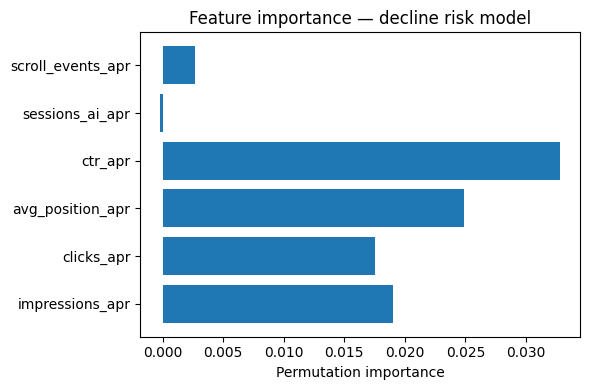

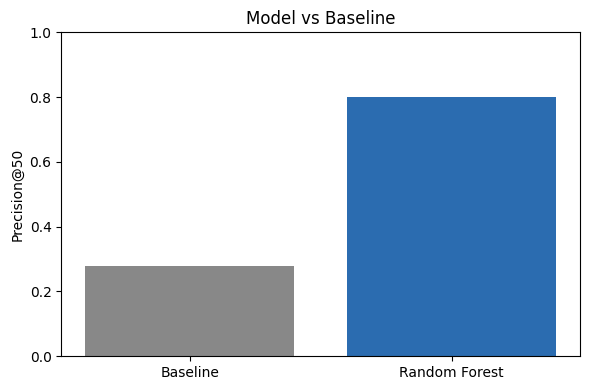

In [7]:
os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

perm = permutation_importance(rf, test_df[features].fillna(0), test_df['is_declining'], n_repeats=10, random_state=42)
plt.figure(figsize=(6,4))
plt.barh(features, perm.importances_mean)
plt.xlabel('Permutation importance'); plt.title('Feature importance — decline risk model')
plt.tight_layout(); plt.savefig('work/figures/feature_importance.png'); plt.show()

plt.figure(figsize=(6,4))
plt.bar(['Baseline','Random Forest'], [p_baseline, p_rf], color=['#888','#2b6cb0'])
plt.ylabel('Precision@50'); plt.ylim(0,1); plt.title('Model vs Baseline')
plt.tight_layout(); plt.savefig('work/figures/model_vs_baseline.png'); plt.show()

metrics = {'precision_at_50_baseline': float(p_baseline), 'precision_at_50_model_grouped': float(p_rf)}
with open('work/outputs/model_metrics.json','w') as f: json.dump(metrics, f, indent=2)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
